In [1]:
# imports
from astropy import wcs
from astropy.coordinates import SkyCoord, Angle
from astropy.cosmology import WMAP9 as cosmo
from astropy.io import fits
from astropy.nddata import Cutout2D
import astropy.units as u
from astropy.visualization import simple_norm
import copy
import matplotlib.pyplot as plt
import numpy as np
from photutils.aperture import SkyEllipticalAperture
import os
from regions import EllipseSkyRegion # https://pypi.org/project/regions/

### Set up details

In [2]:
# user inputs
file = 'example_files/FRB20190608B-ls-dr10-rband.fits'
frbname = 'FRB20190608B'
instr = 'Legacy'                    # telescope-instrument
filter = 'r'                        # image filter
frbra = 334.019875                  # degrees, FRB localization
frbdec = -7.89825                   # degrees, FRB localization
frbuncmajorarcsec = 0.3848413134    # arcsec, 1sigma FRB localization semi-major axis
frbuncminorarcsec = 0.3630021252    # arcsec, 1sigma FRB localization semi-minor axis
frbuncpa = 90                       # deg E of N, 1 sigma FRB localization
galra = '22:16:04.9007'             # HMS, host center
galdec = '-7:53:55.799'             # DMS,  host center
z = 0.1178                          # redshift, if not known put None
r_e_arcsec = 1.7981696              # host effective (half-light) radius, if not known put None
cutout_size = 15                    # arcsec, cutout size for FRB localization 

# set up logging - optional but highly recommended
log = True

### No user inputs required beyond this point, run cells as is

In [3]:
# load required functions

def angular_to_kpc(r_arcsec, redshift):
    """
    Converts angular radius in arcsec to kpc from redshift
    """
    d_A = cosmo.angular_diameter_distance(redshift)
    theta = r_arcsec
    theta_radian = theta*np.pi/180/3600
    distance_Mpc = d_A*theta_radian

    r_kpc = distance_Mpc.to(u.kpc).value
    
    return r_kpc

def create_localization_map(hostimagefile, cutout_size, frbradeg, frbdecdeg, frbmajoraxisarcsec, frbminoraxisarcsec, frbpadeg):
    '''
    Function to create a 2D numpy array FRB localization PDF. Assumes FRB localization is a 2D Gaussian.
    Note: Code modified from addFRBLocalisation function of coflash (https://github.com/adamdeller/coflash)
    Inputs:
        hostimagefile [fits] = image cutout with wcs in arcsec
        cutout_size [int] = size to make FRB image cutout
        frbradec [float] = RA of FRB in degrees
        frbradec [float] = Decl. of FRB in degrees
        frbmajoraxisarcsec [float] = Semi-major axis of FRB localization ellipse
        frbminoraxisarcsec [float] = Semi-minor axis of FRB localization ellipse
        frbpadec [float] = Position angle of FRB localization ellipse in degrees East of North
    Outputs:
        w [astropy WCS objct] = WCS of localization map
        prob [2D numpy array] = PDF of FRB localization 
    '''

    ## convert pa to radians
    frbparad = frbpadeg*np.pi/180.0
    
    ## load in image
    hostimagehdul = fits.open(hostimagefile)

    ## pull out wcs
    w = wcs.WCS(hostimagehdul[0].header, hostimagehdul) # CHANGE INDEX IF NEEDED FOR YOUR IMAGE

    ############################
    # new stuff here
    # make cutout about FRB region to reduce calculation time (important part is getting wcs grid in region, don't care about the pixel values)
    frb_coords = SkyCoord(frbradeg, frbdecdeg, unit='deg', frame='fk5')
    cutout = Cutout2D(hostimagehdul[0].data, frb_coords, cutout_size*u.arcsec, w) # CHANGE INDEX IF NEEDED FOR YOUR IMAGE
    
    # save cutout to fits - this is pretty inefficient, but gets things into the right format to work with rest of code below
    hdu = fits.PrimaryHDU(cutout.data, header=cutout.wcs.to_header())
    hdu.writeto('frb_cutout.fits', overwrite=True)

    # load cutout
    hostimagehdul = fits.open('frb_cutout.fits')
    w = wcs.WCS(hostimagehdul[0].header, hostimagehdul) # CHANGE INDEX IF NEEDED FOR YOUR IMAGE

    ############################

    ## append new hdu to end of hdul
    hostimagehdul.append(hostimagehdul[0].copy())

    ## make deep copy
    hostimagehdul[-1].data = copy.deepcopy(hostimagehdul[-1].data)

    ## update new hdul to add FRB localization
    # set hdu to zero
    hostimagehdul[-1].data -= hostimagehdul[-1].data
    # create subpixel grid 
    oversamplefactor = 1
    subpixgrid = np.zeros(oversamplefactor*oversamplefactor*2).reshape(oversamplefactor*oversamplefactor, 2)
    for i in range(oversamplefactor):
        for j in range(oversamplefactor):
            subpixgrid[i*oversamplefactor + j][0] = (i-oversamplefactor//2)/float(oversamplefactor)
            subpixgrid[i*oversamplefactor + j][1] = (j-oversamplefactor//2)/float(oversamplefactor)
    # add localization to grid
    subpixel_grid_vals = []
    for x in range(hostimagehdul[-1].data.shape[0]):
        for y in range(hostimagehdul[-1].data.shape[1]):
            pixgrid = [[l[0]+x, l[1]+y] for l in subpixgrid]
            radecgrid = w.all_pix2world(pixgrid,0)
            radecoffsets = [[3600*(g[0]-frbradeg)*np.cos(frbdecdeg*np.pi/180), 3600*(g[1]-frbdecdeg)] for g in radecgrid]
            majminoffsets = [[o[0]*np.sin(frbparad) + o[1]*np.cos(frbparad), -o[0]*np.cos(frbparad) + o[1]*np.sin(frbparad)] for o in radecoffsets]
            norm = 1/(2*np.pi*frbmajoraxisarcsec*frbminoraxisarcsec)
            likelihoods = [norm*np.e**(-(o[0])**2/(2*frbmajoraxisarcsec**2)) * np.e**(-(o[1])**2/(2*frbminoraxisarcsec**2)) for o in majminoffsets]
            hostimagehdul[-1].data[y,x] = np.mean(likelihoods)
            subpixel_grid_vals.append(radecgrid)

    ## normalize localization PDF
    imsum = hostimagehdul[-1].data.sum()
    hostimagehdul[-1].data /= imsum

    ## convert map into numpy array
    prob = hostimagehdul[-1].data

    # plot to check localization - will be same scale as the original pixel grid
    ax = plt.subplot(projection=w)
    norm = simple_norm(prob, 'log', percent=99.9)
    #norm = simple_norm(prob, 'linear') # uncomment if getting a division runtime warning
    ax.imshow(prob, norm=norm, origin='lower')
    ax.set_title(f'FRB localization map ({cutout_size:.2f} arcsec)')
    ax.set_xlabel('Right Ascension')
    ax.set_ylabel('Declination')

    return w, prob, subpixel_grid_vals

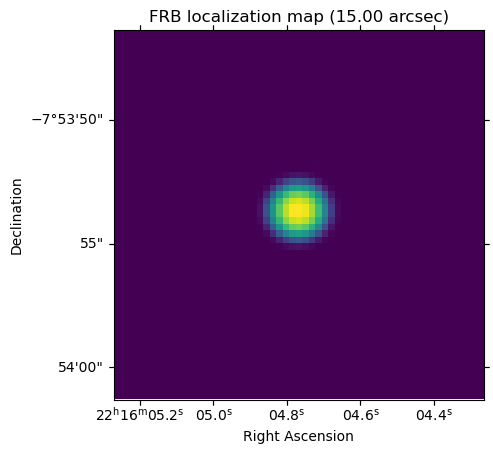

In [4]:
# convert host position to SkyCoord object
gal = SkyCoord(galra, galdec, frame = 'fk5', unit=(u.hourangle, u.deg))

# log it
if log==True:
    with open('{0}_{1}_{2}-band_offset_calcs_log.txt'.format(frbname,instr,filter), 'w') as f:
        f.write('Log of Offset Calculations\n')
        f.write('----------------------------\n')
        f.write('User-input FRB and image details:\n')
        f.write('FRB = '+frbname+'\n')
        f.write('Telescope-instrument = '+instr+'\n')
        f.write('Filter = '+filter+'\n')
        f.write('FRB R.A. = '+str(frbra)+' degrees\n')
        f.write('FRB Decl. = '+str(frbdec)+' degrees\n')
        f.write('FRB Uncertainty semi major axis = ' + str(frbuncmajorarcsec)+' arcsec\n')
        f.write('FRB Uncertainty semi minor axis = ' + str(frbuncminorarcsec)+' arcsec\n')
        f.write('FRB uncertainty angle = '+str(frbuncpa)+' deg E of N\n')
        f.write('Galaxy R.A. = '+str(galra)+'\n')
        f.write('Galaxy Decl. = '+str(galdec)+'\n')
        f.write('z = '+str(z)+'\n')
        f.write('r_e_arcsec = '+str(r_e_arcsec)+'\n')
        f.write('FRB localization cutout size = '+str(cutout_size)+' arcsec\n')
        f.write('-----------------------------------------\n')
        f.close()

# create localization map
w, prob, subpixel_grid = create_localization_map(file, cutout_size, frbra, frbdec, frbuncmajorarcsec, frbuncminorarcsec, frbuncpa)

#### Sanity check localization map

NOTE: if 5sigma ellipse (orange) is beyond the bounds of the cutout, regenerate map in above cell using a larger cutout size

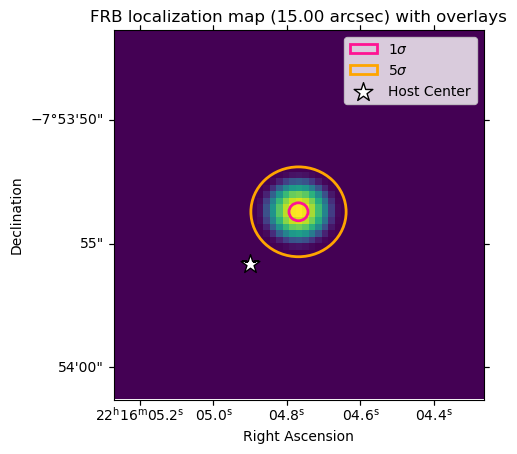

In [5]:
# pull out RA/Dec arrays from wcs
x = np.arange(w.array_shape[1])
y = np.arange(w.array_shape[0])
X, Y = np.meshgrid(x,y)
ra_grid,dec_grid = w.all_pix2world(X,Y,1)

# create frb localization ellipse region
frb_position = SkyCoord(frbra, frbdec, unit='deg', frame='fk5')

# create 5sigma localization region
# height/width are diameters so need *2; angle is deg E of N
sigma = 5
ell_regions = EllipseSkyRegion(frb_position, height=2*sigma*frbuncmajorarcsec*u.arcsec, width=2*sigma*frbuncminorarcsec*u.arcsec, angle = frbuncpa*u.deg)
ell_regions_pixel = ell_regions.to_pixel(w)

# plot localization map as sanity check
ax = plt.subplot(projection=w)

norm = simple_norm(prob, 'log', percent=99.9)
#norm = simple_norm(prob, 'linear') # uncomment if getting a division runtime warning
ax.imshow(prob, norm=norm, cmap='viridis')

# plot 1sigma FRB ellipse
frb_position = SkyCoord(frbra, frbdec, unit='deg', frame='fk5')
frb_ell = SkyEllipticalAperture(frb_position, frbuncmajorarcsec*u.arcsec, frbuncminorarcsec*u.arcsec, frbuncpa*u.deg)
frb_apermap = frb_ell.to_pixel(w)
frb_apermap.plot(color='deeppink', lw=2, label=r'1$\sigma$')

# plot regions (5sigma) ellipse
ell_regions_pixel.plot(color='orange', lw=2, label=r'{}$\sigma$'.format(sigma))

# plot host center
gal_ra_deg = Angle(gal.ra, unit=u.hourangle).degree
gal_dec_deg = Angle(gal.dec, unit=u.degree).degree
ax.scatter(gal_ra_deg, gal_dec_deg, transform=ax.get_transform('fk5'), color='white', ec='black', marker='*', s=200, label='Host Center', zorder=5)
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.set_title(f'FRB localization map ({cutout_size:.2f} arcsec) with overlays')

plt.legend()

In [6]:
# calculate offset from galaxy center at each RA/Dec pair in the cutout
all_ang_seps = []
skycoords = []
for ra,dec in zip(ra_grid, dec_grid):
    pos = SkyCoord(ra, dec, frame='fk5', unit='deg')
    ang_sep = pos.separation(gal).to('arcsec')
    all_ang_seps.append(ang_sep.value)
    skycoords.append(pos)

all_ang_seps = np.array(all_ang_seps)

In [7]:
# check if coordinates exist in localization region; if so, save along with corresponding offset
# and localization weight
coords_in_loc = []
offsets_in_loc = []
weights_in_loc = []
for i in range(len(skycoords)):
    for coord,offset,weight in zip(skycoords[i],all_ang_seps[i],prob[i]):
        if ell_regions.contains(coord,w) == True:
            coords_in_loc.append(coord)
            offsets_in_loc.append(offset)
            weights_in_loc.append(weight)

print(r'There are {} pixel samples within the 5sigma localization region'.format(len(coords_in_loc)))

There are 162 pixel samples within the 5sigma localization region


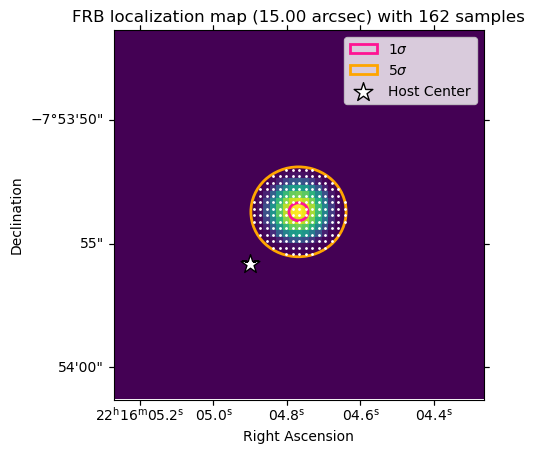

In [8]:
# plot coords in region to sanity check overlap
ax = plt.subplot(projection=w)

norm = simple_norm(prob, 'log', percent=99.9)
#norm = simple_norm(prob, 'linear') # uncomment if getting a division runtime warning
ax.imshow(prob, norm=norm, cmap='viridis')

# plot actual FRB ellipse
frb_position = SkyCoord(frbra, frbdec, unit='deg', frame='fk5')
frb_ell = SkyEllipticalAperture(frb_position, frbuncmajorarcsec*u.arcsec, frbuncminorarcsec*u.arcsec, frbuncpa*u.deg)
frb_apermap = frb_ell.to_pixel(w)
frb_apermap.plot(color='deeppink', lw=2, label=r'1$\sigma$')

# plot regions (5sigma) ellipse
ell_regions_pixel.plot(color='orange', lw=2, label=r'{}$\sigma$'.format(sigma))

# plot host center
gal_ra_deg = Angle(gal.ra, unit=u.hourangle).degree
gal_dec_deg = Angle(gal.dec, unit=u.degree).degree
ax.scatter(gal_ra_deg, gal_dec_deg, transform=ax.get_transform('fk5'), color='white', ec='black', marker='*', s=200, label='Host Center', zorder=5)
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.set_title(f'FRB localization map ({cutout_size:.2f} arcsec) with {len(coords_in_loc)} samples')

plt.legend()

# plot coords in region
for coord in coords_in_loc:
    ax.plot_coord(coord, marker='o', markersize=1, color='white')

In [9]:
# calculate weighted angular offset in 5sigma region
# quantiles
lo_ang = np.quantile(offsets_in_loc, q=0.16, method='inverted_cdf', weights=weights_in_loc)
med_ang = np.quantile(offsets_in_loc, q=0.5, method='inverted_cdf', weights=weights_in_loc)
hi_ang = np.quantile(offsets_in_loc, q=0.84, method='inverted_cdf', weights=weights_in_loc)
print('Weighted angular offset = {0} +{1}/-{2} arcsec'.format(med_ang, hi_ang-med_ang, med_ang-lo_ang))

# mean
avg_ang = np.average(offsets_in_loc, weights=weights_in_loc)
print('Weighted average angular offset = {} arcsec'.format(avg_ang))

# straight-line offset
sep_straightline = frb_position.separation(gal).to('arcsec')
print('Straight-line angular offset = {} arcsec'.format(sep_straightline))

# log it
if log==True:
    with open('{0}_{1}_{2}-band_offset_calcs_log.txt'.format(frbname,instr,filter), 'a') as f:
        f.write('(weighted) Angular offset details:\n')
        f.write('Median = '+str(med_ang)+' arcsec\n')
        f.write('Upper uncertainty (68% C.I.) = '+str(hi_ang-med_ang)+' arcsec\n')
        f.write('Lower uncertainty (68% C.I.) = '+str(med_ang-lo_ang)+' arcsec\n')
        f.write('Mean = '+str(avg_ang)+' arcsec\n')
        f.write('Straight-line angular offset = '+str(sep_straightline)+'\n')
        f.write('-----------------------------------------\n')
        f.close()

Weighted angular offset = 2.524334968993311 +0.35650358934850646/-0.3518066557978594 arcsec
Weighted average angular offset = 2.5178172151625207 arcsec
Straight-line angular offset = 2.8595068066505647 arcsec arcsec


#### Sanity check angular offset distribution

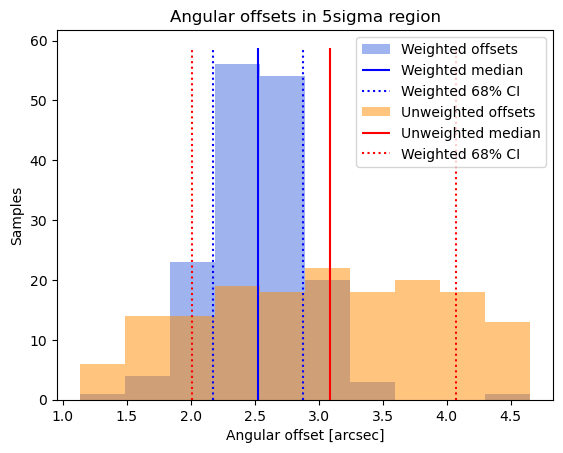

In [10]:
# plot weighted and un-weighted angular offset distributions with statistics for visual inspection

# hacky way to derive weighted distribution
quantiles = np.linspace(0,1,len(coords_in_loc))
weighted_offsets = []
for q in quantiles:
    ang_off = np.quantile(offsets_in_loc, q=q, method='inverted_cdf', weights=weights_in_loc)
    weighted_offsets.append(ang_off)

# calculate stats on unweighted distribution
lo_ang_nw = np.quantile(offsets_in_loc, q=0.16)
med_ang_nw = np.quantile(offsets_in_loc, q=0.5)
hi_ang_nw = np.quantile(offsets_in_loc, q=0.84)

# plot distributions
# weighted
plt.hist(weighted_offsets, color='royalblue', alpha=0.5, label='Weighted offsets')
ymin, ymax = plt.ylim()
plt.vlines(med_ang, ymin, ymax, color='blue', label='Weighted median')
plt.vlines(lo_ang, ymin, ymax, color='blue', linestyle='dotted', label='Weighted 68% CI')
plt.vlines(hi_ang, ymin, ymax, color='blue', linestyle='dotted')

# unweighted
plt.hist(offsets_in_loc, color='darkorange', alpha=0.5, label='Unweighted offsets')
plt.vlines(med_ang_nw, ymin, ymax, color='red', label='Unweighted median')
plt.vlines(lo_ang_nw, ymin, ymax, color='red', linestyle='dotted', label='Weighted 68% CI')
plt.vlines(hi_ang_nw, ymin, ymax, color='red', linestyle='dotted')

plt.xlabel('Angular offset [arcsec]')
plt.ylabel('Samples')
plt.title('Angular offsets in 5sigma region')
plt.legend()

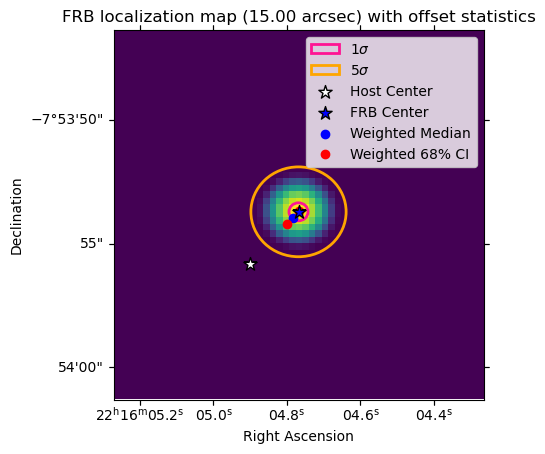

In [11]:
# plot coords in region to sanity check overlap
ax = plt.subplot(projection=w)

norm = simple_norm(prob, 'log', percent=99.9)
#norm = simple_norm(prob, 'linear') # uncomment if getting a division runtime warning
ax.imshow(prob, norm=norm, cmap='viridis')
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.set_title(f'FRB localization map ({cutout_size:.2f} arcsec) with offset statistics')

# plot actual FRB ellipse
frb_position = SkyCoord(frbra, frbdec, unit='deg', frame='fk5')
frb_ell = SkyEllipticalAperture(frb_position, frbuncmajorarcsec*u.arcsec, frbuncminorarcsec*u.arcsec, frbuncpa*u.deg)
frb_apermap = frb_ell.to_pixel(w)
frb_apermap.plot(color='deeppink', lw=2, label=r'1$\sigma$')

# plot regions (5sigma) ellipse
ell_regions_pixel.plot(color='orange', lw=2, label=r'{}$\sigma$'.format(sigma))

# plot host center
gal_ra_deg = Angle(gal.ra, unit=u.hourangle).degree
gal_dec_deg = Angle(gal.dec, unit=u.degree).degree
ax.scatter(gal_ra_deg, gal_dec_deg, transform=ax.get_transform('fk5'), color='white', ec='black', marker='*', s=100, label='Host Center', zorder=5)

# plot FRB center
ax.scatter(frbra, frbdec, transform=ax.get_transform('fk5'), color='blue', ec='black', marker='*', s=100, zorder=5, label='FRB Center')

# calculate and plot weighted median coordinate
# test straightline separation
sep = sep_straightline
pa = gal.position_angle(frb_position).to(u.deg) # position angle between FRB and galaxy center
coord_straightline = frb_position.directional_offset_by(pa, sep)

# median weighted separation
sep = med_ang*u.arcsec
coord_med = gal.directional_offset_by(pa, sep)
coord_med_ra_deg = Angle(coord_med.ra).degree
coord_med_dec_deg = Angle(coord_med.dec).degree
ax.scatter(coord_med_ra_deg, coord_med_dec_deg, transform=ax.get_transform('fk5'), color='blue', marker='o', label='Weighted Median')

# lower-bound weighted separation
sep = lo_ang*u.arcsec
coord_lo = gal.directional_offset_by(pa, sep)
coord_lo_ra_deg = Angle(coord_lo.ra).degree
coord_lo_dec_deg = Angle(coord_lo.dec).degree
ax.scatter(coord_lo_ra_deg, coord_lo_dec_deg, transform=ax.get_transform('fk5'), color='red', marker='o', label='Weighted 68% CI')

# upper-bound weighted separation
sep = hi_ang*u.arcsec
coord_hi = gal.directional_offset_by(pa, sep)
coord_hi_ra_deg = Angle(coord_hi.ra).degree
coord_hi_dec_deg = Angle(coord_hi.dec).degree
ax.scatter(coord_hi_ra_deg, coord_hi_dec_deg, transform=ax.get_transform('fk5'), color='red', marker='o')


plt.legend(loc='best')

In [12]:
# calculated weighted physical offset in 5sigma region

if z is not None:
    physical_separations = angular_to_kpc(np.array(offsets_in_loc), z)

    # quantiles
    lo_phys = np.quantile(physical_separations, q=0.16, method='inverted_cdf', weights=weights_in_loc)
    med_phys = np.quantile(physical_separations, q=0.5, method='inverted_cdf', weights=weights_in_loc)
    hi_phys = np.quantile(physical_separations, q=0.84, method='inverted_cdf', weights=weights_in_loc)
    print('Weighted physical offset = {0} +{1}/-{2} kpc'.format(med_phys, hi_phys-med_phys, med_phys-lo_phys))

    # mean
    avg_phys = np.average(physical_separations, weights=weights_in_loc)
    print('Weighted average physical offset = {} kpc'.format(avg_phys))

    # log it
    if log==True:
        with open('{0}_{1}_{2}-band_offset_calcs_log.txt'.format(frbname,instr,filter), 'a') as f:
            f.write('(weighted) Physical offset details:\n')
            f.write('Median = '+str(med_phys)+' kpc\n')
            f.write('Upper uncertainty (68% C.I.) = '+str(hi_phys-med_phys)+' kpc\n')
            f.write('Lower uncertainty (68% C.I.) = '+str(med_phys-lo_phys)+' kpc\n')
            f.write('Mean = '+str(avg_phys)+' kpc\n')
            f.write('-----------------------------------------\n')
            f.close()

else:
    print('Redshift not specified, skipping')

Weighted physical offset = 5.433128118562259 +0.7673029528367952/-0.7571937390999102 kpc
Weighted average physical offset = 5.419099951919202 kpc


In [13]:
# calculate host-normalized offsets in 5sigma region

if r_e_arcsec is not None:

    # calculate distribution of host normalized offsets
    host_norm_offsets = np.array(offsets_in_loc)/r_e_arcsec

    # pull out statistics
    med_hno = np.quantile(host_norm_offsets, q=0.50, method='inverted_cdf', weights=weights_in_loc)
    lo_hno = np.quantile(host_norm_offsets, q=0.16, method='inverted_cdf', weights=weights_in_loc)
    hi_hno = np.quantile(host_norm_offsets, q=0.84, method='inverted_cdf', weights=weights_in_loc)
    print('Host-normalized offset = {0} + {1}/-{2} r_e'.format(med_hno, hi_hno-med_hno, med_hno-lo_hno))

    # log it
    if log==True:
        with open('{0}_{1}_{2}-band_offset_calcs_log.txt'.format(frbname,instr,filter), 'a') as f:
            f.write('Host-normalized offset details:\n')
            f.write('Median = '+str(med_hno)+'\n')
            f.write('Upper uncertainty (68% C.I.) = '+str(hi_hno-med_hno)+'\n')
            f.write('Lower uncertainty (68% C.I.) = '+str(med_hno-lo_hno))
            f.close()

else:
    print('Host effective radius not specified, skipping')

Host-normalized offset = 1.4038358611964694 + 0.19825915717210796/-0.1956470934654102 r_e


## Optional cells to clean up working directory

In [14]:
# delete temporary cutout image
if os.path.exists('frb_cutout.fits'):
    os.remove('frb_cutout.fits')
print('Removed temporary cutout image')

Removed temporary cutout image


In [15]:
# move log to example_files directory
os.rename('{0}_{1}_{2}-band_offset_calcs_log.txt'.format(frbname,instr,filter), 'example_files/{0}_{1}_{2}-band_offset_calcs_log.txt'.format(frbname,instr,filter))
print('Moved log to example_files')

Moved log to example_files
